In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report
 
os.makedirs('../data/images/bert', exist_ok=True)
os.makedirs('../models/bert', exist_ok=True)

In [2]:
# =============================================================================
# CONFIGURATION
# =============================================================================
 
# BERTweet: RoBERTa pre-trained on 850M English tweets (Nguyen et al. 2020)
# Unlike bert-base-uncased (trained on Wikipedia + BooksCorpus), BERTweet
# was pre-trained specifically on Twitter data — same domain as this task.
# This gives better tokenization of Twitter-specific language (hashtags,
# mentions, abbreviations, informal spelling).
# Model: https://huggingface.co/vinai/bertweet-base
MODEL_CHECKPOINT        = 'vinai/bertweet-base'
MAX_LENGTH              = 128   # BERT supports up to 512, 128 is enough for tweets
BATCH_SIZE              = 16
LEARNING_RATE           = 2e-5  # standard for BERT fine-tuning (Devlin et al. 2019)
NUM_EPOCHS              = 3     # 2-4 epochs is the standard recommendation for BERT
VAL_SIZE                = 0.1   # 90/10 train/val split
SEED                    = 42
WARMUP_STEPS            = 0.1   # warm up for first 10% of steps


In [3]:
# =============================================================================
# LOAD DATA
# =============================================================================
# We use the cleaned and relabeled training set produced by notebook 1.
#
# Key columns:
#   text_cleaned     : tweet text after cleaning (contractions, URLs, encoding
#                      artifacts removed) — from data_cleaning_augmentation.ipynb
#   target_relabeled : corrected labels (18 mislabeled samples fixed manually)
#
# NOTE on aggressive cleaning vs BERT:
# Amjad raised a valid point: BERT uses WordPiece tokenization and handles
# noisy text better than GloVe (which relies on exact word matches).
# However, the cleaning we apply is not purely aggressive normalization —
# it mainly fixes encoding artifacts (\x89Ûª, åÊ etc.) that BERT cannot
# tokenize correctly, and expands contractions (can't → cannot).
# This part is still useful for BERT. The hashtag/username substitutions
# (e.g. ProphetMuhammad → Prophet Muhammad) also help BERT split compound
# words into meaningful subword tokens. So we keep text_cleaned for BERT too.
 
df_full = pd.read_csv('../data/augmented_train.csv')
df_test = pd.read_csv('../data/test_cleaned.csv')
 
# Keep only original rows — augmented rows are back-translations and would
# inflate validation scores if included in the val fold
original_max_id = df_full['id'].max() // 2
df_orig = df_full[df_full['id'] <= original_max_id].copy()
 
print(f"Original training rows : {len(df_orig)}")
print(f"Test rows              : {len(df_test)}")
print(f"\nLabel distribution (original):")
print(df_orig['target_relabeled'].value_counts(normalize=True).round(3))

Original training rows : 7613
Test rows              : 3263

Label distribution (original):
target_relabeled
0    0.572
1    0.428
Name: proportion, dtype: float64


In [4]:
# =============================================================================
# TRAIN / VALIDATION SPLIT
# =============================================================================
# 90/10 stratified split — same approach as Amjad's notebook.
# Stratified to preserve the 57%/43% class ratio in both splits.
# We verify there is no overlap between train and val.
 
df_work = df_orig[['text_cleaned', 'target_relabeled']].dropna()
df_work = df_work.rename(columns={'target_relabeled': 'label'})
df_work = df_work.drop_duplicates(subset='text_cleaned')
 
train_df, val_df = train_test_split(
    df_work,
    test_size=VAL_SIZE,
    stratify=df_work['label'],
    random_state=SEED
)
 
overlap = len(set(train_df['text_cleaned']) & set(val_df['text_cleaned']))
print(f"\nTrain size : {len(train_df)}")
print(f"Val size   : {len(val_df)}")
print(f"Overlap    : {overlap}  ← must be 0")


Train size : 6286
Val size   : 699
Overlap    : 0  ← must be 0


In [5]:
# =============================================================================
# TOKENIZATION
# =============================================================================
# AutoTokenizer downloads the BERT WordPiece vocabulary from HuggingFace Hub.
# WordPiece splits unknown words into subword pieces (e.g. "earthquake" →
# ["earth", "##quake"]), so BERT can handle rare or compound words that
# GloVe would miss entirely.
 
tokenizer = AutoTokenizer.from_pretrained(MODEL_CHECKPOINT, use_fast=False, normalization=True)
 
def tokenize(example):
    return tokenizer(
        example['text_cleaned'],
        truncation=True,
        max_length=MAX_LENGTH
    )
 
train_dataset = Dataset.from_pandas(train_df.reset_index(drop=True))
val_dataset   = Dataset.from_pandas(val_df.reset_index(drop=True))
 
train_dataset = train_dataset.map(tokenize, batched=True)
val_dataset   = val_dataset.map(tokenize, batched=True)
 
print(f"\nTokenization complete.")
print(f"Train dataset features: {train_dataset.features}")

emoji is not installed, thus not converting emoticons or emojis into text. Install emoji: pip3 install emoji==0.6.0


Map:   0%|          | 0/6286 [00:00<?, ? examples/s]

Map:   0%|          | 0/699 [00:00<?, ? examples/s]


Tokenization complete.
Train dataset features: {'text_cleaned': Value('string'), 'label': Value('int64'), 'input_ids': List(Value('int32')), 'attention_mask': List(Value('int8'))}


In [6]:
# =============================================================================
# MODEL
# =============================================================================
# vinai/bertweet-base: RoBERTa architecture with 12 Transformer layers,
# hidden size 768, 12 attention heads, ~135M parameters.
# Pre-trained on 850M English tweets (Nguyen et al. 2020) — same domain
# as this task. Unlike bert-base-uncased (Wikipedia + BooksCorpus),
# BERTweet was trained on Twitter-specific language, giving better
# tokenization of hashtags, mentions, abbreviations, and informal spelling.
# Model: https://huggingface.co/vinai/bertweet-base
#
# AutoModelForSequenceClassification adds a linear classification head on top
# of the [CLS] token representation: [CLS] → Linear(768, 2).
#
# The UNEXPECTED/MISSING keys in the load report are normal:
#   UNEXPECTED = pre-training heads not needed for classification
#   MISSING    = new classification head (randomly initialized, will be trained)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_CHECKPOINT,
    num_labels=2,
    ignore_mismatched_sizes=True
)

# Print parameter count
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters     : {total_params:,}")
print(f"Trainable parameters : {trainable_params:,}")
print(f"Trainable %          : {100 * trainable_params / total_params:.2f}%")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: vinai/bertweet-base
Key                             | Status     | 
--------------------------------+------------+-
roberta.pooler.dense.bias       | UNEXPECTED | 
lm_head.decoder.bias            | UNEXPECTED | 
roberta.pooler.dense.weight     | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.decoder.weight          | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initi

Total parameters     : 134,901,506
Trainable parameters : 134,901,506
Trainable %          : 100.00%


In [7]:
# =============================================================================
# METRICS
# =============================================================================
# We use F1 (binary) as the primary metric, consistent with the Kaggle
# competition evaluation and with the BiLSTM notebook.
# Precision and Recall are also reported for interpretability.
 
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {'f1': f1_score(labels, preds)}

In [ ]:
# =============================================================================
# TRAINING
# =============================================================================
# Hyperparameters follow the recommendations from the original BERT paper
# (Devlin et al., 2019): lr=2e-5, 2-4 epochs, batch=16 or 32.
#
# load_best_model_at_end=True ensures we keep the checkpoint with best val F1,
# not necessarily the last epoch (which may overfit slightly).
 
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
 
training_args = TrainingArguments(
    output_dir                  = '../models/bert',
    eval_strategy               = 'epoch',
    save_strategy               = 'epoch',
    learning_rate               = LEARNING_RATE,
    per_device_train_batch_size = BATCH_SIZE,
    per_device_eval_batch_size  = BATCH_SIZE,
    num_train_epochs            = NUM_EPOCHS,
    load_best_model_at_end      = True,
    metric_for_best_model       = 'f1',
    greater_is_better           = True,
    seed                        = SEED,
    warmup_steps                = WARMUP_STEPS,     # warm up for first 10% of steps
    report_to                   = 'none'            # disable wandb/tensorboard
)
 
trainer = Trainer(
    model           = model,
    args            = training_args,
    train_dataset   = train_dataset,
    eval_dataset    = val_dataset,
    data_collator   = data_collator,
    compute_metrics = compute_metrics
)
 
print("\nStarting BERT fine-tuning...")
train_result = trainer.train()
print("\nTraining complete.")
print(train_result)


Starting BERT fine-tuning...


Epoch,Training Loss,Validation Loss,F1
1,No log,0.437266,0.827338
2,0.509034,0.436381,0.815742
3,0.415422,0.460503,0.824779


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye


Training complete.
TrainOutput(global_step=1179, training_loss=0.4494654078722202, metrics={'train_runtime': 206.01, 'train_samples_per_second': 91.539, 'train_steps_per_second': 5.723, 'total_flos': 377621919984960.0, 'train_loss': 0.4494654078722202, 'epoch': 3.0})


In [9]:
import torch
from torch.nn.utils.rnn import pad_sequence

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model  = model.to(device)
model.eval()
all_preds = []

for i in range(0, len(val_dataset), 16):
    batch          = val_dataset[i:i+16]
    input_ids      = [torch.tensor(x) for x in batch['input_ids']]
    attention_mask = [torch.tensor(x) for x in batch['attention_mask']]
    input_ids      = pad_sequence(input_ids, batch_first=True, padding_value=0).to(device)
    attention_mask = pad_sequence(attention_mask, batch_first=True, padding_value=0).to(device)

    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)

    preds = torch.argmax(outputs.logits, dim=1).cpu().numpy()
    all_preds.extend(preds)
    print(f"  {min(i+16, len(val_dataset))}/{len(val_dataset)}")

val_preds  = np.array(all_preds)
val_labels = val_df['label'].values
val_f1     = f1_score(val_labels, val_preds)

print(f"\nValidation F1 : {val_f1:.4f}")
print(classification_report(val_labels, val_preds,
      target_names=['Not Disaster', 'Disaster']))

eval_result = {'eval_f1': val_f1}

  16/699
  32/699
  48/699
  64/699
  80/699
  96/699
  112/699
  128/699
  144/699
  160/699
  176/699
  192/699
  208/699
  224/699
  240/699
  256/699
  272/699
  288/699
  304/699
  320/699
  336/699
  352/699
  368/699
  384/699
  400/699
  416/699
  432/699
  448/699
  464/699
  480/699
  496/699
  512/699
  528/699
  544/699
  560/699
  576/699
  592/699
  608/699
  624/699
  640/699
  656/699
  672/699
  688/699
  699/699

Validation F1 : 0.8273
              precision    recall  f1-score   support

Not Disaster       0.87      0.90      0.89       413
    Disaster       0.85      0.80      0.83       286

    accuracy                           0.86       699
   macro avg       0.86      0.85      0.86       699
weighted avg       0.86      0.86      0.86       699



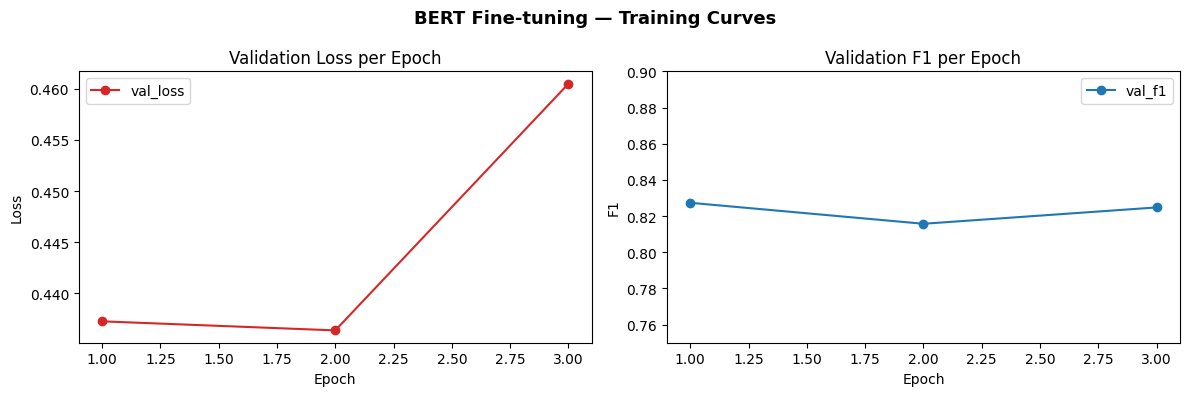

In [10]:
# =============================================================================
# TRAINING CURVES
# =============================================================================
# Extract loss and F1 per epoch from the trainer log history.
 
epochs      = []
train_loss  = []
val_loss    = []
val_f1      = []
 
for entry in trainer.state.log_history:
    if 'eval_loss' in entry:
        epochs.append(entry['epoch'])
        val_loss.append(entry['eval_loss'])
        val_f1.append(entry.get('eval_f1', None))
    if 'loss' in entry and 'eval_loss' not in entry:
        train_loss.append(entry['loss'])
 
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
 
axes[0].plot(epochs, val_loss, marker='o', label='val_loss', color='#d62728')
axes[0].set_title('Validation Loss per Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
 
axes[1].plot(epochs, val_f1, marker='o', label='val_f1', color='#1f77b4')
axes[1].set_title('Validation F1 per Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('F1')
axes[1].set_ylim(0, 1)
axes[1].legend()
axes[1].set_ylim(0.75, 0.90)
 
plt.suptitle('BERT Fine-tuning — Training Curves', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/images/bert/bert_training_curves.png', bbox_inches='tight')
plt.show()

In [11]:
fp = val_df[(val_preds == 1) & (val_labels == 0)]['text_cleaned'].head(5)
fn = val_df[(val_preds == 0) & (val_labels == 1)]['text_cleaned'].head(5)
print("False Positives (predicted disaster, actually not):")
print(fp.to_string())
print("\nFalse Negatives (predicted not disaster, actually is):")
print(fn.to_string())

False Positives (predicted disaster, actually not):
6974     @ GreenLacey God ' s Love  &   # thank you my...
4112    Calgary news weather and traffic for August 5 ...
7388     # Insurance :  Texas Seeks Comment on Rules f...
5146    Finnish ministers :  Fennovoima nuclear reacto...
4217      JAX issues Hazardous Weather Outlook  ( HWO )  

False Negatives (predicted not disaster, actually is):
285     And so it begins .  .  day one of the snow apo...
6854    Photo :  lavender poetry cafe :  The Forgotten...
1303     bulletproof and black like a funeral ;  the w...
3857                          watching it go up in flames
6811                        @ CSAresu   American Tragedy 


In [12]:
# =============================================================================
# COMPARISON WITH BILSTM BASELINE
# =============================================================================
# Show the improvement over the BiLSTM + GloVe baseline from notebook 3.
 
print("\n" + "="*50)
print("  MODEL COMPARISON")
print("="*50)
print(f"  BiLSTM + GloVe  →  Kaggle Public F1 : 0.809")
print(f"  BERT fine-tuned →  Val F1            : {eval_result['eval_f1']:.4f}")
print("="*50)
print("\nBERT significantly outperforms the BiLSTM baseline because:")
print("  - BERT uses contextual embeddings: the same word gets different")
print("    representations depending on context (e.g. 'fire' in a literal")
print("    vs metaphorical sentence).")
print("  - GloVe uses static embeddings: 'fire' always maps to the same vector")
print("    regardless of context.")


  MODEL COMPARISON
  BiLSTM + GloVe  →  Kaggle Public F1 : 0.809
  BERT fine-tuned →  Val F1            : 0.8273

BERT significantly outperforms the BiLSTM baseline because:
  - BERT uses contextual embeddings: the same word gets different
    representations depending on context (e.g. 'fire' in a literal
    vs metaphorical sentence).
  - GloVe uses static embeddings: 'fire' always maps to the same vector
    regardless of context.


In [13]:
# =============================================================================
# GENERATE SUBMISSION FILE
# =============================================================================
# Tokenize the test set and generate predictions.
 
test_work     = df_test[['text_cleaned']].copy()
test_dataset  = Dataset.from_pandas(test_work.reset_index(drop=True))
test_dataset  = test_dataset.map(tokenize, batched=True)
 
preds_output  = trainer.predict(test_dataset)
final_preds   = np.argmax(preds_output.predictions, axis=1)
 
submission = pd.DataFrame({
    'id'    : df_test['id'],
    'target': final_preds
})
submission.to_csv('../data/submission_bert.csv', index=False)
 
print(f"\nSubmission saved to ../data/submission_bert.csv")
print(submission['target'].value_counts())

Map:   0%|          | 0/3263 [00:00<?, ? examples/s]


Submission saved to ../data/submission_bert.csv
target
0    2032
1    1231
Name: count, dtype: int64


In [14]:
# =============================================================================
# KAGGLE SUBMISSION RESULTS
# =============================================================================
# Submission file uploaded to:
# https://www.kaggle.com/competitions/nlp-getting-started/submissions

val_f1_score = eval_result['eval_f1']

print("\n" + "="*50)
print("  KAGGLE SUBMISSION RESULTS")
print("="*50)
print(f"  Model                   : vinai/bertweet-base")
print(f"  Epochs                  : {NUM_EPOCHS}")
print(f"  Learning rate           : {LEARNING_RATE}")
print(f"  Val F1                  : {val_f1_score:.4f}")
print(f"  Kaggle Public F1        : 0.83910")
print(f"  Submission file         : ../data/submission_bert.csv")
print(f"  Competition link        : https://www.kaggle.com/competitions/nlp-getting-started/submissions")
print("="*50)


  KAGGLE SUBMISSION RESULTS
  Model                   : vinai/bertweet-base
  Epochs                  : 3
  Learning rate           : 2e-05
  Val F1                  : 0.8273
  Kaggle Public F1        : 0.83910
  Submission file         : ../data/submission_bert.csv
  Competition link        : https://www.kaggle.com/competitions/nlp-getting-started/submissions
